Build our own CNN as baseline before moving to pretrained models.

### Reload data

We will eventually move this reusable code into the src folder.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

print("PyTorch:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.14.0+cu130
Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
PROJECT_ROOT = Path.cwd().parent

METADATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "metadata_splits.csv"
)

df = pd.read_csv(METADATA_PATH)

# Image paths are stored relative to the project root
df["image_path"] = df["image_path"].map(lambda p: str(PROJECT_ROOT / p))

print(df.shape)
print(df["split"].value_counts())

(10015, 9)
split
train    7002
val      1532
test     1481
Name: count, dtype: int64


In [3]:
#Define the classes
CLASS_NAMES = [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc",
]

class_to_idx = {
    name: idx for idx, name in enumerate(CLASS_NAMES)
}

idx_to_class = {
    idx: name for name, idx in class_to_idx.items()
}

NUM_CLASSES = len(CLASS_NAMES)

print(class_to_idx)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [4]:
#Recreate data input pipeline
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [5]:
#Dataset
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = class_to_idx[row["dx"]]

        return image, label

In [6]:
#Dataloaders
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "val"].copy()
test_df = df[df["split"] == "test"].copy()

train_dataset = HAM10000Dataset(train_df, train_transform)
val_dataset = HAM10000Dataset(val_df, eval_transform)
test_dataset = HAM10000Dataset(test_df, eval_transform)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

Build CNN

In [7]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)

        return x

In [8]:
#Move to GPU if available
model = BaselineCNN(num_classes=NUM_CLASSES).to(device)

print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Linear(in_features=256, out_features=7, bias=True)
)


In [9]:
total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 390,215
Trainable parameters: 390,215


In [12]:
#!pip install torchsummary

In [13]:
import torchsummary

torchsummary.summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
              ReLU-2         [-1, 32, 224, 224]               0
         MaxPool2d-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 64, 112, 112]          18,496
              ReLU-5         [-1, 64, 112, 112]               0
         MaxPool2d-6           [-1, 64, 56, 56]               0
            Conv2d-7          [-1, 128, 56, 56]          73,856
              ReLU-8          [-1, 128, 56, 56]               0
         MaxPool2d-9          [-1, 128, 28, 28]               0
           Conv2d-10          [-1, 256, 28, 28]         295,168
             ReLU-11          [-1, 256, 28, 28]               0
AdaptiveAvgPool2d-12            [-1, 256, 1, 1]               0
           Linear-13                    [-1, 7]           1,799
Total params: 390,215
Trainable params:

We have our standard sequence of convolutional layers with pooling and ReLU activation, but note that at the end we have an AdaptiveAvgPool which takes a (-1,256,28,28) tensor which is 256 features maps, each one 28x28, and then it produces tensor of size (-1,256,1,1), so in other words it reduces each 28x28 feature map down to a SINGLE value.  Why do that?

These 256 single values are then fed into fully connected linear classifier for the classes.

But why do we want to reduce 28x28 down to 1x1?

Turns out each feature map looks for signals of some type of visual feature, e.g. dark features, certain textures, irregular patterns.  The average then just sees whether that feature is present ANYWHERE in the image.  The adaptive piece means we want 1x1 output regardless of the size of the input, which is a nice flexibility in the design.

In [14]:
images, labels = next(iter(train_loader))

print("Input:", images.shape)

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

print("Output:", outputs.shape)
print("Labels:", labels.shape)

Input: torch.Size([32, 3, 224, 224])
Output: torch.Size([32, 7])
Labels: torch.Size([32])


In [15]:
#Confirm output 
print(outputs[0])

tensor([ 0.0572, -0.0501, -0.0581,  0.0011,  0.0155, -0.0357, -0.0034],
       device='cuda:0')


In [16]:
#Convert to probabilities with softmax
probabilities = torch.softmax(outputs, dim=1)

print("Logits:")
print(outputs[0])

print("\nProbabilities:")
print(probabilities[0])

print("\nProbability sum:")
print(probabilities[0].sum())

Logits:
tensor([ 0.0572, -0.0501, -0.0581,  0.0011,  0.0155, -0.0357, -0.0034],
       device='cuda:0')

Probabilities:
tensor([0.1528, 0.1372, 0.1361, 0.1444, 0.1465, 0.1392, 0.1438],
       device='cuda:0')

Probability sum:
tensor(1., device='cuda:0')


In [17]:
#Predictions
predictions = outputs.argmax(dim=1)

print("Predictions:", predictions[:10])
print("True labels:", labels[:10])

Predictions: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')
True labels: tensor([5, 5, 2, 5, 4, 5, 5, 5, 2, 2], device='cuda:0')


In [18]:
#Example prediction
i = 0

pred_idx = predictions[i].item()
true_idx = labels[i].item()

print("Predicted:", idx_to_class[pred_idx])
print("Actual:", idx_to_class[true_idx])

Predicted: akiec
Actual: nv


In [19]:
#Build out loss function
criterion = nn.CrossEntropyLoss()

loss = criterion(outputs, labels)

print("Loss:", loss.item())

Loss: 1.9689431190490723


Note: We feed in the raw logit outputs into CrossEntropyLoss, we don't feed in the softmax probabilities.  nn.CrossEntropyLoss handles the softmax calculations internally in numerically stable way so better to feed in raw logits and let it do the softmax.

In [20]:
#Buidl optimizer to update the weights
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

Before unleashing the entire training loop, lets build a single training loop to ensure the loss is moving in the right direction. 

Recall the core training loop:
- Zero out previous gradients with `optimizer.zero_grad()` (otherwise gradients will accumulate, since pytorch tensors remember everything)
- Make prediction with `output = model(input)`
- Calculate loss with something like `loss = loss_fn(output,truth)`, e.g. in our case of multi-class classification we can use loss function of `CrossEntropyLoss()`
- Compute gradients by running `loss.backward()`, which runs back propagation to compute how much loss function would change if we made small nudge to every trainable parameter in the network
- Use the optimizer to actually update all weights by running `optimizer.step()`

In [21]:
optimizer.zero_grad()

outputs = model(images)

loss = criterion(outputs, labels)

loss.backward()

optimizer.step()

In [ ]:
#Build sample training loop for one batch with fresh model
model = BaselineCNN(num_classes=NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

Loss after optimization: 1.9689431190490723


In [23]:
#Grab one batch
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])


In [24]:
NUM_STEPS = 100

loss_history = []
accuracy_history = []

model.train()

for step in range(NUM_STEPS):

    # 1. Clear gradients from previous step
    optimizer.zero_grad()

    # 2. Forward pass
    outputs = model(images)

    # 3. Calculate loss
    loss = criterion(outputs, labels)

    # 4. Backpropagation
    loss.backward()

    # 5. Update model weights
    optimizer.step()

    # Calculate accuracy on this batch
    predictions = outputs.argmax(dim=1)
    accuracy = (predictions == labels).float().mean()

    loss_history.append(loss.item())
    accuracy_history.append(accuracy.item())

    if step % 10 == 0 or step == NUM_STEPS - 1:
        print(
            f"Step {step:3d} | "
            f"Loss: {loss.item():.4f} | "
            f"Accuracy: {accuracy.item():.3f}"
        )

Step   0 | Loss: 1.8150 | Accuracy: 0.719
Step  10 | Loss: 0.8332 | Accuracy: 0.719
Step  20 | Loss: 0.7397 | Accuracy: 0.719
Step  30 | Loss: 0.6499 | Accuracy: 0.719
Step  40 | Loss: 0.5521 | Accuracy: 0.688
Step  50 | Loss: 0.4362 | Accuracy: 0.844
Step  60 | Loss: 0.3305 | Accuracy: 0.875
Step  70 | Loss: 0.2330 | Accuracy: 0.969
Step  80 | Loss: 0.1634 | Accuracy: 0.938
Step  90 | Loss: 0.1037 | Accuracy: 0.969
Step  99 | Loss: 0.0545 | Accuracy: 1.000


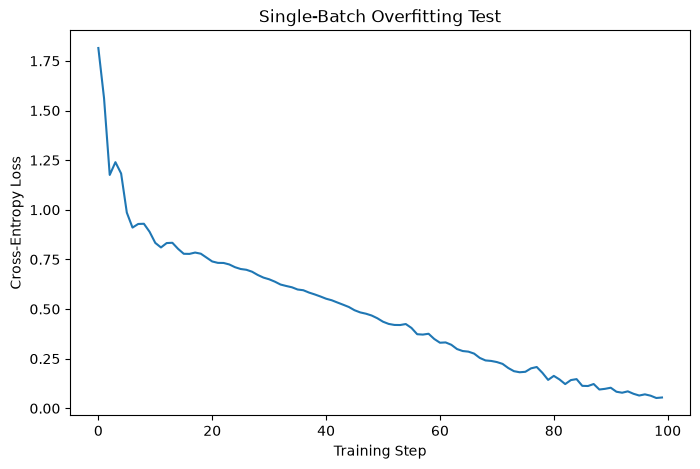

In [25]:
#Plot
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Training Step")
plt.ylabel("Cross-Entropy Loss")
plt.title("Single-Batch Overfitting Test")

plt.show()

OK, we've shown on one batch that our model and training loop is working, so now lets build the bigger version to train on the whole training set.

In [26]:
#Reset model
model = BaselineCNN(num_classes=NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [27]:
#Train one epoch
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [28]:
#And for validation
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

Notice some differences:
- Training uses `model.train()` while validation uses `model.eval()`.  The train version activates things like Dropout and batch normalization.  Even though we dont' have them here (yet), this is good pattern to use since we use these techniques during training to ensure better learning and better back propagation that gets around vanishing gradient, things that don't matter during validation on new data.
- Validation uses torch.no_grad(), which turns off the gradient tracking.  Doesn't change any behavior, but helps to save memory by avoiding the unnecessary gradient tracking when doing validation and we don't need to do any backprop.

In [29]:
#Compare baseline accuracy of just predicting highest class
majority_class = val_df["dx"].value_counts().idxmax()

majority_accuracy = (
    val_df["dx"] == majority_class
).mean()

print("Majority class:", majority_class)
print(f"Majority-class validation accuracy: {majority_accuracy:.3f}")

Majority class: nv
Majority-class validation accuracy: 0.675


In [30]:
#Train on entire dataset for one epoch!
train_loss, train_acc = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

val_loss, val_acc = evaluate(
    model,
    val_loader,
    criterion,
    device
)

print(f"Train Loss: {train_loss:.4f}")
print(f"Train Accuracy: {train_acc:.3f}")

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.3f}")

Train Loss: 1.0509
Train Accuracy: 0.665
Validation Loss: 0.9768
Validation Accuracy: 0.675


In [31]:
#See if it is just predicting the majority class nv
from collections import Counter

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().tolist())
        all_labels.extend(labels.tolist())

In [32]:
prediction_counts = Counter(all_predictions)

for idx in range(NUM_CLASSES):
    print(
        f"{idx_to_class[idx]:5s}: "
        f"{prediction_counts[idx]:4d}"
    )

akiec:    0
bcc  :    0
bkl  :    0
df   :    0
mel  :    0
nv   : 1532
vasc :    0


So it is essentially always saying nv!  Not great, but just one epoch in so lets keep going.

In [33]:
NUM_EPOCHS = 10

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch + 1:2d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.3f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.3f}"
    )

Epoch  1/10 | Train Loss: 0.9330 | Train Acc: 0.667 | Val Loss: 0.9004 | Val Acc: 0.675
Epoch  2/10 | Train Loss: 0.8924 | Train Acc: 0.671 | Val Loss: 0.9134 | Val Acc: 0.681
Epoch  3/10 | Train Loss: 0.8739 | Train Acc: 0.677 | Val Loss: 0.8752 | Val Acc: 0.700
Epoch  4/10 | Train Loss: 0.8525 | Train Acc: 0.681 | Val Loss: 0.8546 | Val Acc: 0.695
Epoch  5/10 | Train Loss: 0.8392 | Train Acc: 0.688 | Val Loss: 0.8510 | Val Acc: 0.710
Epoch  6/10 | Train Loss: 0.8273 | Train Acc: 0.690 | Val Loss: 0.8351 | Val Acc: 0.711
Epoch  7/10 | Train Loss: 0.8058 | Train Acc: 0.696 | Val Loss: 0.8086 | Val Acc: 0.715
Epoch  8/10 | Train Loss: 0.7926 | Train Acc: 0.710 | Val Loss: 0.8153 | Val Acc: 0.718
Epoch  9/10 | Train Loss: 0.7727 | Train Acc: 0.714 | Val Loss: 0.7735 | Val Acc: 0.719
Epoch 10/10 | Train Loss: 0.7622 | Train Acc: 0.715 | Val Loss: 0.7761 | Val Acc: 0.727


In [34]:
#Look at performance for each class
from collections import Counter

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().tolist())
        all_labels.extend(labels.tolist())

prediction_counts = Counter(all_predictions)
actual_counts = Counter(all_labels)

print("Predicted vs Actual")
print("-" * 31)

for idx in range(NUM_CLASSES):
    print(
        f"{idx_to_class[idx]:5s} | "
        f"Predicted: {prediction_counts[idx]:4d} | "
        f"Actual: {actual_counts[idx]:4d}"
    )

Predicted vs Actual
-------------------------------
akiec | Predicted:   17 | Actual:   51
bcc   | Predicted:   85 | Actual:   77
bkl   | Predicted:  184 | Actual:  157
df    | Predicted:    0 | Actual:   19
mel   | Predicted:   81 | Actual:  170
nv    | Predicted: 1158 | Actual: 1034
vasc  | Predicted:    7 | Actual:   24


In [ ]:
#Explore other metrics like F1 that give all classes equal weight
#Accuracy like House of Representatives; F1 like Senate (all states get equal weight)
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_predictions,
        labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES,
        digits=3,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

       akiec      0.471     0.157     0.235        51
         bcc      0.341     0.377     0.358        77
         bkl      0.413     0.484     0.446       157
          df      0.000     0.000     0.000        19
         mel      0.543     0.259     0.351       170
          nv      0.821     0.920     0.868      1034
        vasc      0.714     0.208     0.323        24

    accuracy                          0.727      1532
   macro avg      0.472     0.343     0.369      1532
weighted avg      0.701     0.727     0.701      1532



In [36]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(
    all_labels,
    all_predictions
)

print(f"Accuracy:          {val_accuracies[-1]:.3f}")
print(f"Balanced Accuracy: {balanced_acc:.3f}")

Accuracy:          0.727
Balanced Accuracy: 0.343


Balanced accuracy (34%) is a nice intuitive metric (easier to explain than F1 score).  Here the big drop (34% balanced accuracy vs 72% overall accuracy) shows how much we are still being skewed by the majority class (nv, which makes up 67%).

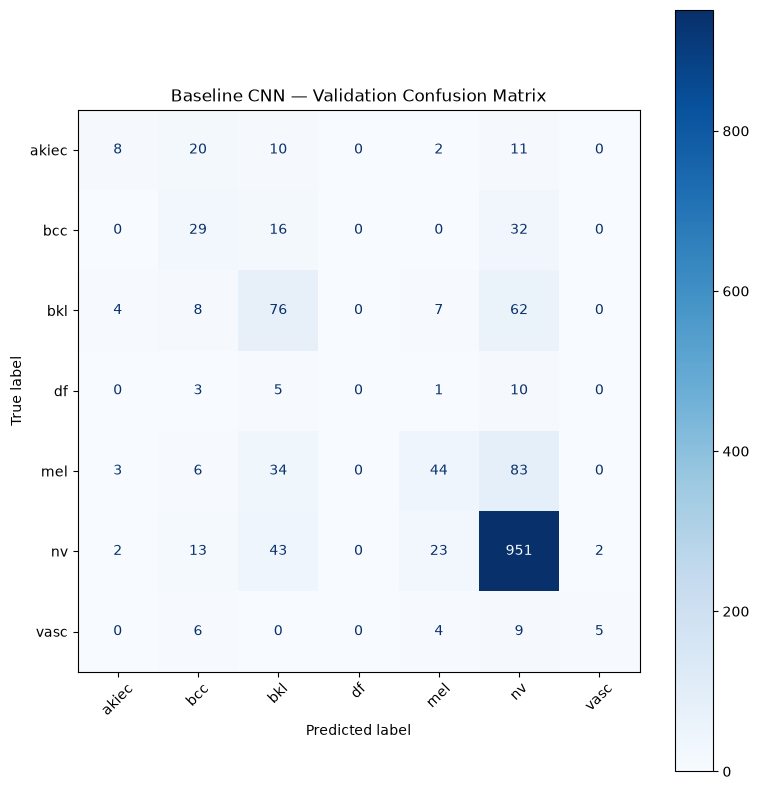

In [37]:
#Plot confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 8))

ConfusionMatrixDisplay.from_predictions(
    all_labels,
    all_predictions,
    display_labels=CLASS_NAMES,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)

ax.set_title("Baseline CNN — Validation Confusion Matrix")

plt.tight_layout()
plt.show()